# Simple chromVAR Exploration for DOGMA-seq TFs

This notebook is a lightweight companion to your existing TF-pair notebooks. It focuses only on the `chromvar_deviations` matrix stored in the DOGMA-seq `AnnData` object and answers three practical questions:

1. How many transcription factors from your TF list are present in `chromvar_deviations`?
2. What does the chromVAR signal look like overall?
3. How correlated are the chromVAR deviation scores across TFs of interest?

In ATAC-seq, we measure chromatin accessibility rather than gene expression. chromVAR summarizes accessibility around motif instances and reports a deviation score per cell for each motif. A positive chromVAR deviation means that motif-associated peaks are more accessible than expected in that cell, while a negative value means they are less accessible than expected.


## Why This Is Useful

ATAC-seq gives a readout of open chromatin, which is often used as a proxy for regulatory activity. chromVAR is especially helpful because it compresses many peaks into motif-level activity scores, making it easier to ask TF-centered questions.

A few interpretation notes:

- chromVAR scores reflect motif accessibility enrichment, not direct TF protein abundance.
- multiple TFs can share similar motifs, so motif-level signal is not always uniquely attributable to one TF.
- cluster-level summaries are often easier to interpret than single-cell values because single-cell ATAC-derived measurements can be noisy.


In [54]:
from pathlib import Path
import re
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='talk')


## Configuration

These defaults are filled in with your requested paths and settings. The notebook assumes `chromvar_deviations` is already stored in `adata.obsm` as a cell-by-feature table.


In [55]:
CONFIG = {
    'adata_path': '/Users/cherkass/Desktop/Leslie_Lab/scrna_patientEFGHJL_all_semisup_stacas_KP_broadclusters_updated.h5ad',
    'tf_list_path': '/Users/cherkass/Desktop/Leslie_Lab/TF_pairs/TF_list.csv',
    'rna_pair_csv_path': '/Users/cherkass/Desktop/Leslie_Lab/TF_pairs/top_tf_pairs_logFC_dogma.csv',
    'cluster_col': 'celltype_new',
    'lineage_col': None,
    'chromvar_source': 'obsm',
    'chromvar_key': 'chromvar_deviations',
}

CONFIG


{'adata_path': '/Users/cherkass/Desktop/Leslie_Lab/scrna_patientEFGHJL_all_semisup_stacas_KP_broadclusters_updated.h5ad',
 'tf_list_path': '/Users/cherkass/Desktop/Leslie_Lab/TF_pairs/TF_list.csv',
 'rna_pair_csv_path': '/Users/cherkass/Desktop/Leslie_Lab/TF_pairs/top_tf_pairs_logFC_dogma.csv',
 'cluster_col': 'celltype_new',
 'lineage_col': None,
 'chromvar_source': 'obsm',
 'chromvar_key': 'chromvar_deviations'}

In [56]:
def validate_config(config):
    for key in ['adata_path', 'tf_list_path', 'rna_pair_csv_path']:
        path = Path(config[key])
        if not path.exists():
            raise FileNotFoundError(f'Missing required file for {key}: {path}')

    if config['chromvar_source'] not in {'obsm', 'layer', 'X', 'dataframe'}:
        raise ValueError("chromvar_source must be one of: 'obsm', 'layer', 'X', 'dataframe'")


def load_tf_list(tf_list_path):
    tf_df = pd.read_csv(tf_list_path)
    tf_series = tf_df.iloc[:, 0].astype(str).str.strip()
    tf_series = tf_series[tf_series.ne('')].drop_duplicates().reset_index(drop=True)
    return tf_series


def strip_motif_suffix(name):
    return re.sub(r'_[0-9]+$', '', str(name))


def get_chromvar_df(adata, config):
    source = config['chromvar_source']
    key = config['chromvar_key']

    if source == 'obsm':
        if key not in adata.obsm:
            raise KeyError(f'{key} not found in adata.obsm')
        chromvar = adata.obsm[key]
    elif source == 'layer':
        if key not in adata.layers:
            raise KeyError(f'{key} not found in adata.layers')
        chromvar = adata.layers[key]
    elif source == 'X':
        chromvar = adata.X
    else:
        chromvar = pd.read_csv(key, index_col=0)

    if isinstance(chromvar, pd.DataFrame):
        chromvar_df = chromvar.copy()
    else:
        chromvar_df = pd.DataFrame(chromvar, index=adata.obs_names)

    if chromvar_df.index.equals(adata.obs_names) is False:
        chromvar_df.index = adata.obs_names

    if chromvar_df.columns.isnull().any() or any(str(c).startswith('Unnamed') for c in chromvar_df.columns):
        chromvar_df.columns = [f'feature_{i}' for i in range(chromvar_df.shape[1])]

    return chromvar_df


validate_config(CONFIG)

adata = ad.read_h5ad(CONFIG['adata_path'])
tf_list = load_tf_list(CONFIG['tf_list_path'])
rna_pairs = pd.read_csv(CONFIG['rna_pair_csv_path'])
chromvar_df = get_chromvar_df(adata, CONFIG)

cluster_labels = adata.obs[CONFIG['cluster_col']].astype(str)
chromvar_base_names = pd.Index([strip_motif_suffix(col) for col in chromvar_df.columns])
chromvar_name_map = pd.Series(chromvar_df.columns, index=chromvar_base_names)

print(f'AnnData shape: {adata.shape}')
print(f'chromVAR matrix shape: {chromvar_df.shape}')
print(f'Number of TFs in TF list: {tf_list.nunique()}')
print(f'Number of TF motifs in chromVAR matrix: {chromvar_base_names.nunique()}')


AnnData shape: (20635, 25500)
chromVAR matrix shape: (20635, 870)
Number of TFs in TF list: 82
Number of TF motifs in chromVAR matrix: 870


## 1. TF Overlap Between Your TF List and `chromvar_deviations`

The motif columns in `chromvar_deviations` include suffixes like `_14`, so the notebook removes that numeric suffix before matching to your TF list.


In [57]:
shared_tf = sorted(set(tf_list).intersection(set(chromvar_base_names)))
missing_tf = sorted(set(tf_list) - set(chromvar_base_names))

rna_pair_tfs = sorted(set(rna_pairs['TF1']).union(set(rna_pairs['TF2'])))
shared_rna_pair_tf = sorted(set(rna_pair_tfs).intersection(set(chromvar_base_names)))

summary_df = pd.DataFrame({
    'metric': [
        'TFs in TF list',
        'Unique TF motifs in chromVAR',
        'TF list TFs found in chromVAR',
        'TF list TFs missing from chromVAR',
        'TFs appearing in RNA pair CSV',
        'RNA pair TFs also found in chromVAR',
    ],
    'value': [
        int(tf_list.nunique()),
        int(chromvar_base_names.nunique()),
        int(len(shared_tf)),
        int(len(missing_tf)),
        int(len(rna_pair_tfs)),
        int(len(shared_rna_pair_tf)),
    ]
})

display(summary_df)

print('TFs from TF_list.csv found in chromVAR:')
display(pd.DataFrame({'shared_tf': shared_tf}))

print('TFs from TF_list.csv not found in chromVAR:')
display(pd.DataFrame({'missing_tf': missing_tf}))


,metric,value
0,TFs in TF list,82
1,Unique TF motifs in chromVAR,870
2,TF list TFs found in chromVAR,51
3,TF list TFs missing from chromVAR,31
4,TFs appearing in RNA pair CSV,31
5,RNA pair TFs also found in chromVAR,20


TFs from TF_list.csv found in chromVAR:


,shared_tf
0,ASCL1
1,BACH2
2,BATF
3,BCL6
4,BHLHE40
5,CREM
6,EGR2
7,EOMES
8,ETS1
9,ETV7


TFs from TF_list.csv not found in chromVAR:


,missing_tf
0,ASXL1
1,BCL2
2,BRD4
3,BRD7
4,BRG1
5,CBLB
6,CTBP2
7,DNMT3A
8,EZH2
9,GCN5


## 2. Basic Plots to Understand the chromVAR Dataset

These first-pass plots answer slightly different questions:

- What is the overall distribution of chromVAR deviation scores?
- Which TF motifs vary the most across cells?
- Do cluster-level averages show recognizable regulatory structure?

Because motif accessibility can be noisy cell-to-cell, the cluster-level heatmap is often one of the easiest summaries to interpret.


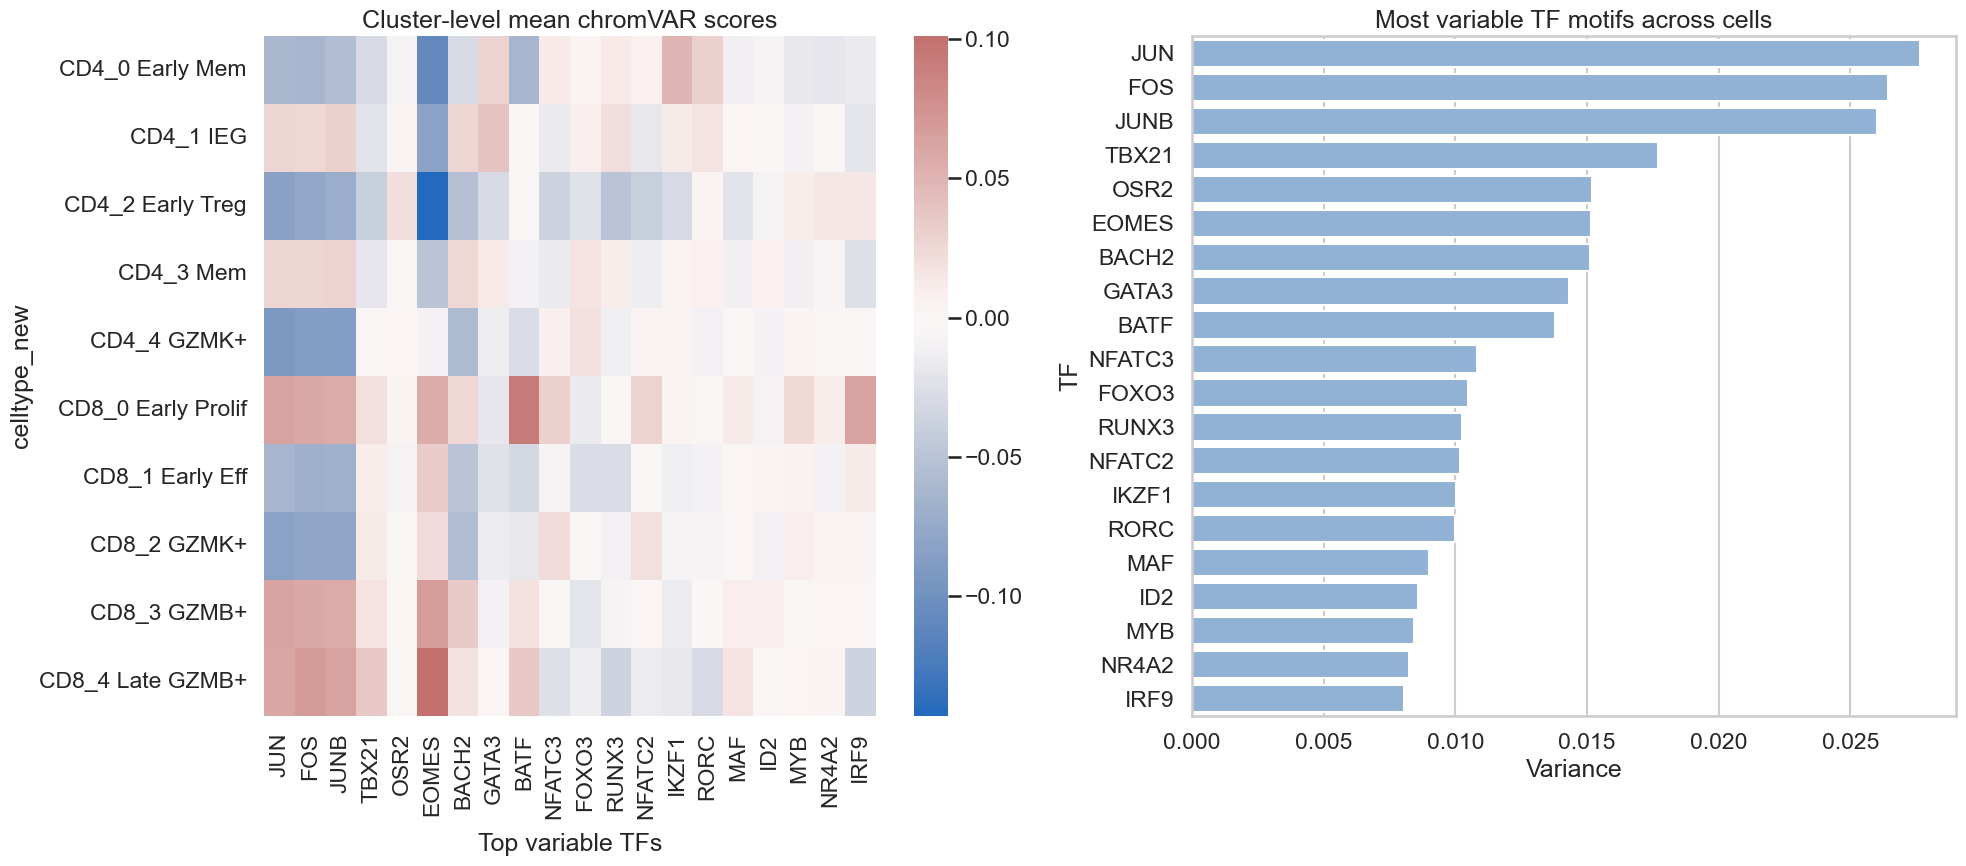

In [58]:
plot_tfs = shared_tf.copy()
if len(plot_tfs) == 0:
    raise ValueError('No TFs from the TF list were found in chromVAR.')

plot_columns = chromvar_name_map.loc[plot_tfs].tolist()
chromvar_tf_df = chromvar_df.loc[:, plot_columns].copy()
chromvar_tf_df.columns = plot_tfs

value_sample = chromvar_tf_df.to_numpy().ravel()
if value_sample.size > 200000:
    rng = np.random.default_rng(42)
    value_sample = rng.choice(value_sample, size=200000, replace=False)

tf_variance = chromvar_tf_df.var(axis=0).sort_values(ascending=False)
top_variable_tfs = tf_variance.head(min(20, len(tf_variance)))

cluster_means = chromvar_tf_df.groupby(cluster_labels).mean()
cluster_means = cluster_means.loc[sorted(cluster_means.index)]
cluster_heatmap = cluster_means.loc[:, top_variable_tfs.index]

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

sns.barplot(x=top_variable_tfs.values, y=top_variable_tfs.index, ax=axes[1], color="#86b1e0")
axes[1].set_title('Most variable TF motifs across cells')
axes[1].set_xlabel('Variance')
axes[1].set_ylabel('TF')

sns.heatmap(cluster_heatmap, cmap='vlag', center=0, ax=axes[0])
axes[0].set_title('Cluster-level mean chromVAR scores')
axes[0].set_xlabel('Top variable TFs', labelpad=10)
axes[0].set_ylabel(CONFIG['cluster_col'])

plt.tight_layout()
plt.show()


## Optional Cluster Summary Table

This table can help connect the heatmap back to specific cluster-level values.


In [59]:
display(cluster_heatmap.round(3))


,JUN,FOS,JUNB,TBX21,OSR2,EOMES,BACH2,GATA3,BATF,NFATC3,FOXO3,RUNX3,NFATC2,IKZF1,RORC,MAF,ID2,MYB,NR4A2,IRF9
celltype_new,,,,,,,,,,,,,,,,,,,,
CD4_0 Early Mem,-0.060,-0.062,-0.056,-0.029,-0.008,-0.110,-0.030,0.028,-0.063,0.013,0.004,0.013,0.007,0.049,0.030,-0.012,-0.008,-0.018,-0.019,-0.017
CD4_1 IEG,0.027,0.026,0.030,-0.021,0.005,-0.082,0.027,0.039,-0.004,-0.016,0.009,0.022,-0.019,0.012,0.018,0.000,-0.003,-0.009,-0.004,-0.021
CD4_2 Early Treg,-0.085,-0.078,-0.072,-0.040,0.021,-0.143,-0.052,-0.030,-0.001,-0.036,-0.025,-0.050,-0.040,-0.029,0.004,-0.021,-0.008,0.011,0.014,0.014
CD4_3 Mem,0.027,0.027,0.029,-0.019,-0.001,-0.049,0.027,0.013,-0.011,-0.016,0.018,0.010,-0.014,0.006,0.007,-0.012,0.007,-0.012,-0.005,-0.026
CD4_4 GZMK+,-0.092,-0.087,-0.087,-0.003,0.000,-0.009,-0.059,-0.014,-0.027,0.008,0.019,-0.013,0.003,0.003,-0.011,-0.002,-0.010,0.003,-0.004,-0.003
CD8_0 Early Prolif,0.063,0.060,0.056,0.020,0.003,0.056,0.026,-0.019,0.093,0.030,-0.016,-0.002,0.028,0.005,-0.001,0.012,-0.008,0.023,0.010,0.064
CD8_1 Early Eff,-0.062,-0.069,-0.067,0.011,-0.008,0.034,-0.049,-0.024,-0.032,-0.007,-0.027,-0.028,-0.002,-0.013,-0.009,0.003,0.004,0.006,-0.010,0.012
CD8_2 GZMK+,-0.084,-0.079,-0.079,0.011,-0.004,0.022,-0.058,-0.015,-0.019,0.022,-0.002,-0.011,0.019,-0.007,-0.008,0.001,-0.011,0.009,0.004,0.004
CD8_3 GZMB+,0.062,0.059,0.058,0.018,-0.005,0.068,0.035,-0.009,0.019,-0.003,-0.021,-0.007,0.002,-0.015,-0.004,0.009,0.008,-0.003,0.001,0.001


## 3. Heatmap of Pairwise TF Correlations in `chromvar_deviations`

This section computes TF-by-TF correlations across cells using the chromVAR deviation scores. High positive correlation means the two motifs tend to be accessible in the same cells, while negative correlation suggests opposing accessibility patterns.

The first heatmap uses every TF from your TF list that is present in chromVAR. The second is a more focused version restricted to TFs that also appear in your RNA pair CSV.


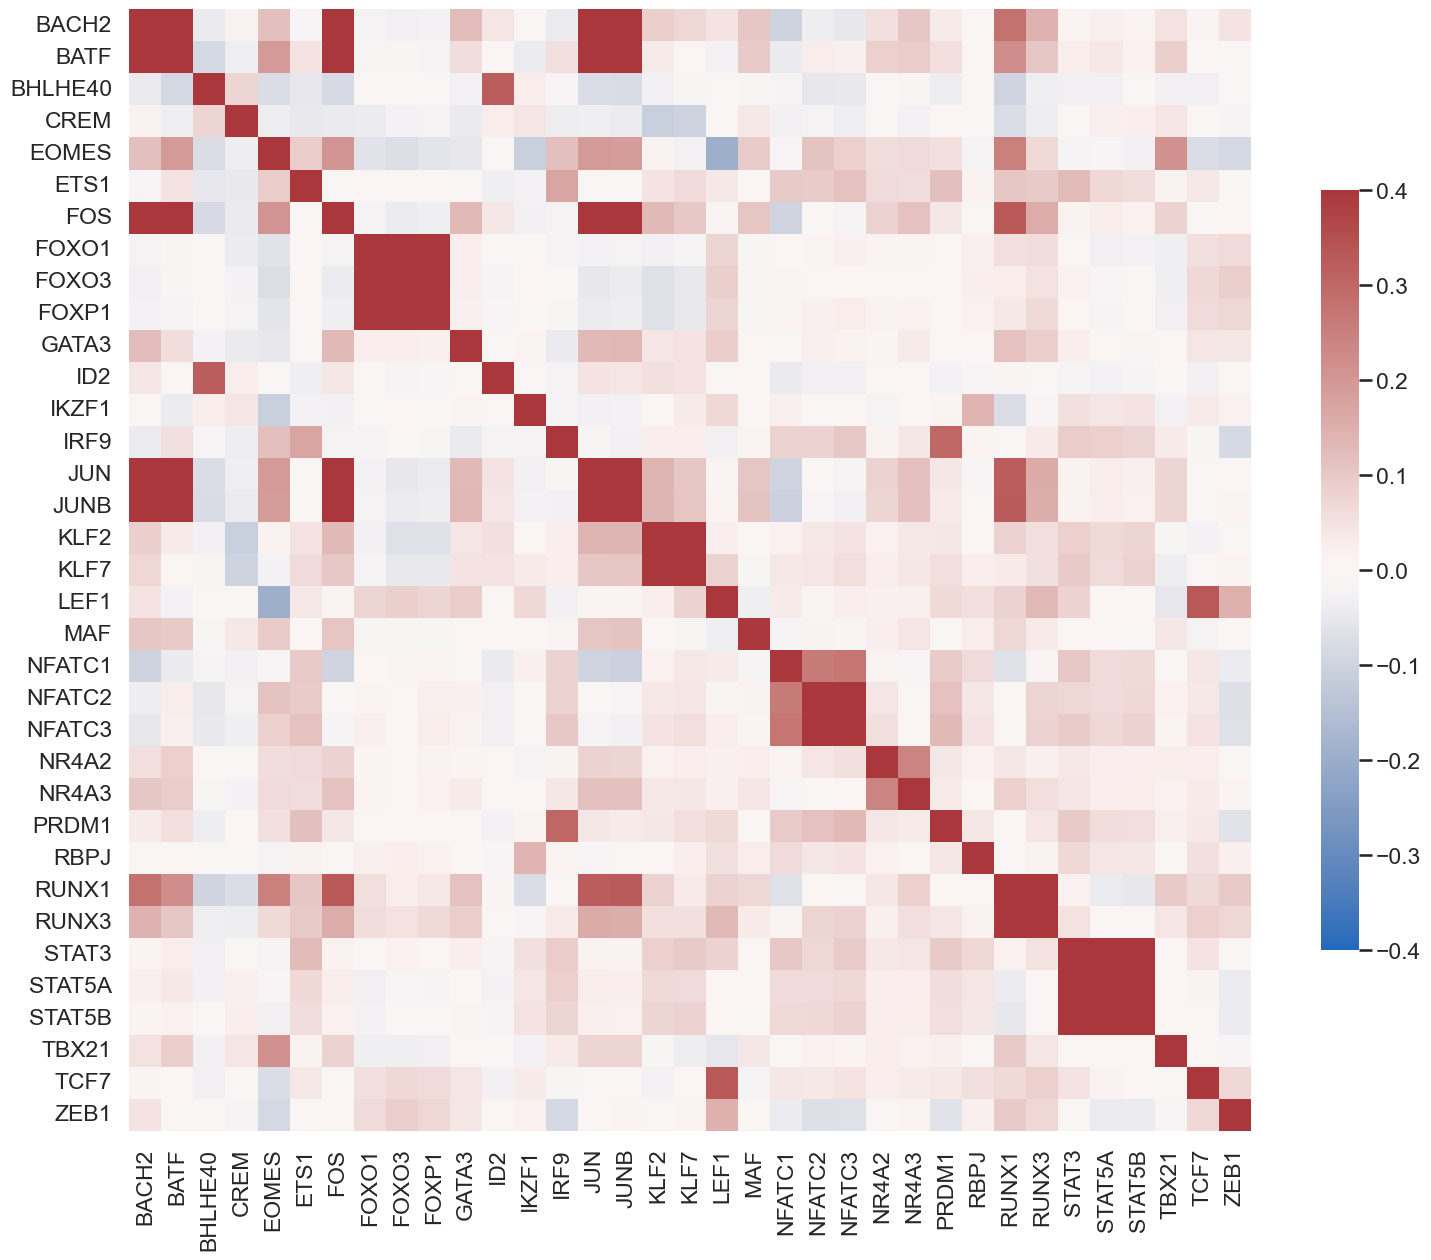

In [60]:
corr_all = chromvar_tf_df.corr(method="spearman")

# Order TFs based on the saved clustermap ordering.
tf_order_df = pd.read_csv('/Users/cherkass/Desktop/Leslie_Lab/TF_pairs/dendrogram_order.csv')
tf_order = tf_order_df['TF'].astype(str).tolist()

# Keep only TFs that are actually present in the chromVAR correlation matrix.
missing_order_tfs = [tf for tf in tf_order if tf not in corr_all.index]
present_order_tfs = [tf for tf in tf_order if tf in corr_all.index]

if missing_order_tfs:
    print(
        'Warning: The following TFs from the order list are missing in the correlation matrix '
        f'and will be skipped: {missing_order_tfs}'
    )

if not present_order_tfs:
    raise ValueError('None of the TFs in tf_order_from_logFC_clustermap.csv were found in the correlation matrix.')

corr_all = corr_all.loc[present_order_tfs, present_order_tfs]

fig, ax = plt.subplots(figsize=(max(10, 0.45 * corr_all.shape[0]), max(8, 0.45 * corr_all.shape[0])))
sns.heatmap(corr_all, cmap='vlag', center=0, vmin=-0.4, vmax=0.4, square=True, ax=ax, cbar_kws={'shrink': 0.5})
ax.set_title('') #Pairwise chromVAR correlations for TFs in TF_list.csv
plt.tight_layout()
plt.show()


In [61]:
#print lowest correlated TF pairs
corr_pairs = corr_all.where(np.triu(np.ones(corr_all.shape), k=1).astype(bool)).stack().reset_index()
corr_pairs.columns = ['TF1', 'TF2', 'correlation']
lowest_corr_pairs = corr_pairs.nsmallest(15, 'correlation')
print('Lowest correlated TF pairs:')
display(lowest_corr_pairs)

Lowest correlated TF pairs:


,TF1,TF2,correlation
143,EOMES,LEF1,-0.194508
137,EOMES,IKZF1,-0.110454
111,CREM,KLF2,-0.109596
409,JUNB,NFATC1,-0.104518
19,BACH2,NFATC1,-0.102624
112,CREM,KLF7,-0.100115
91,BHLHE40,RUNX1,-0.099438
390,JUN,NFATC1,-0.098362
202,FOS,NFATC1,-0.098191
34,BATF,BHLHE40,-0.089020


## Interpretation Notes

- Strong positive chromVAR correlation can reflect shared biology, shared lineage programs, or similar motif families.
- Negative correlations can highlight mutually exclusive cell states.
- If you want a cleaner biological signal, a useful next step is to compute correlations on cluster means instead of individual cells.
- Another useful follow-up is to compare RNA expression and chromVAR motif activity side-by-side for the same TF panel.


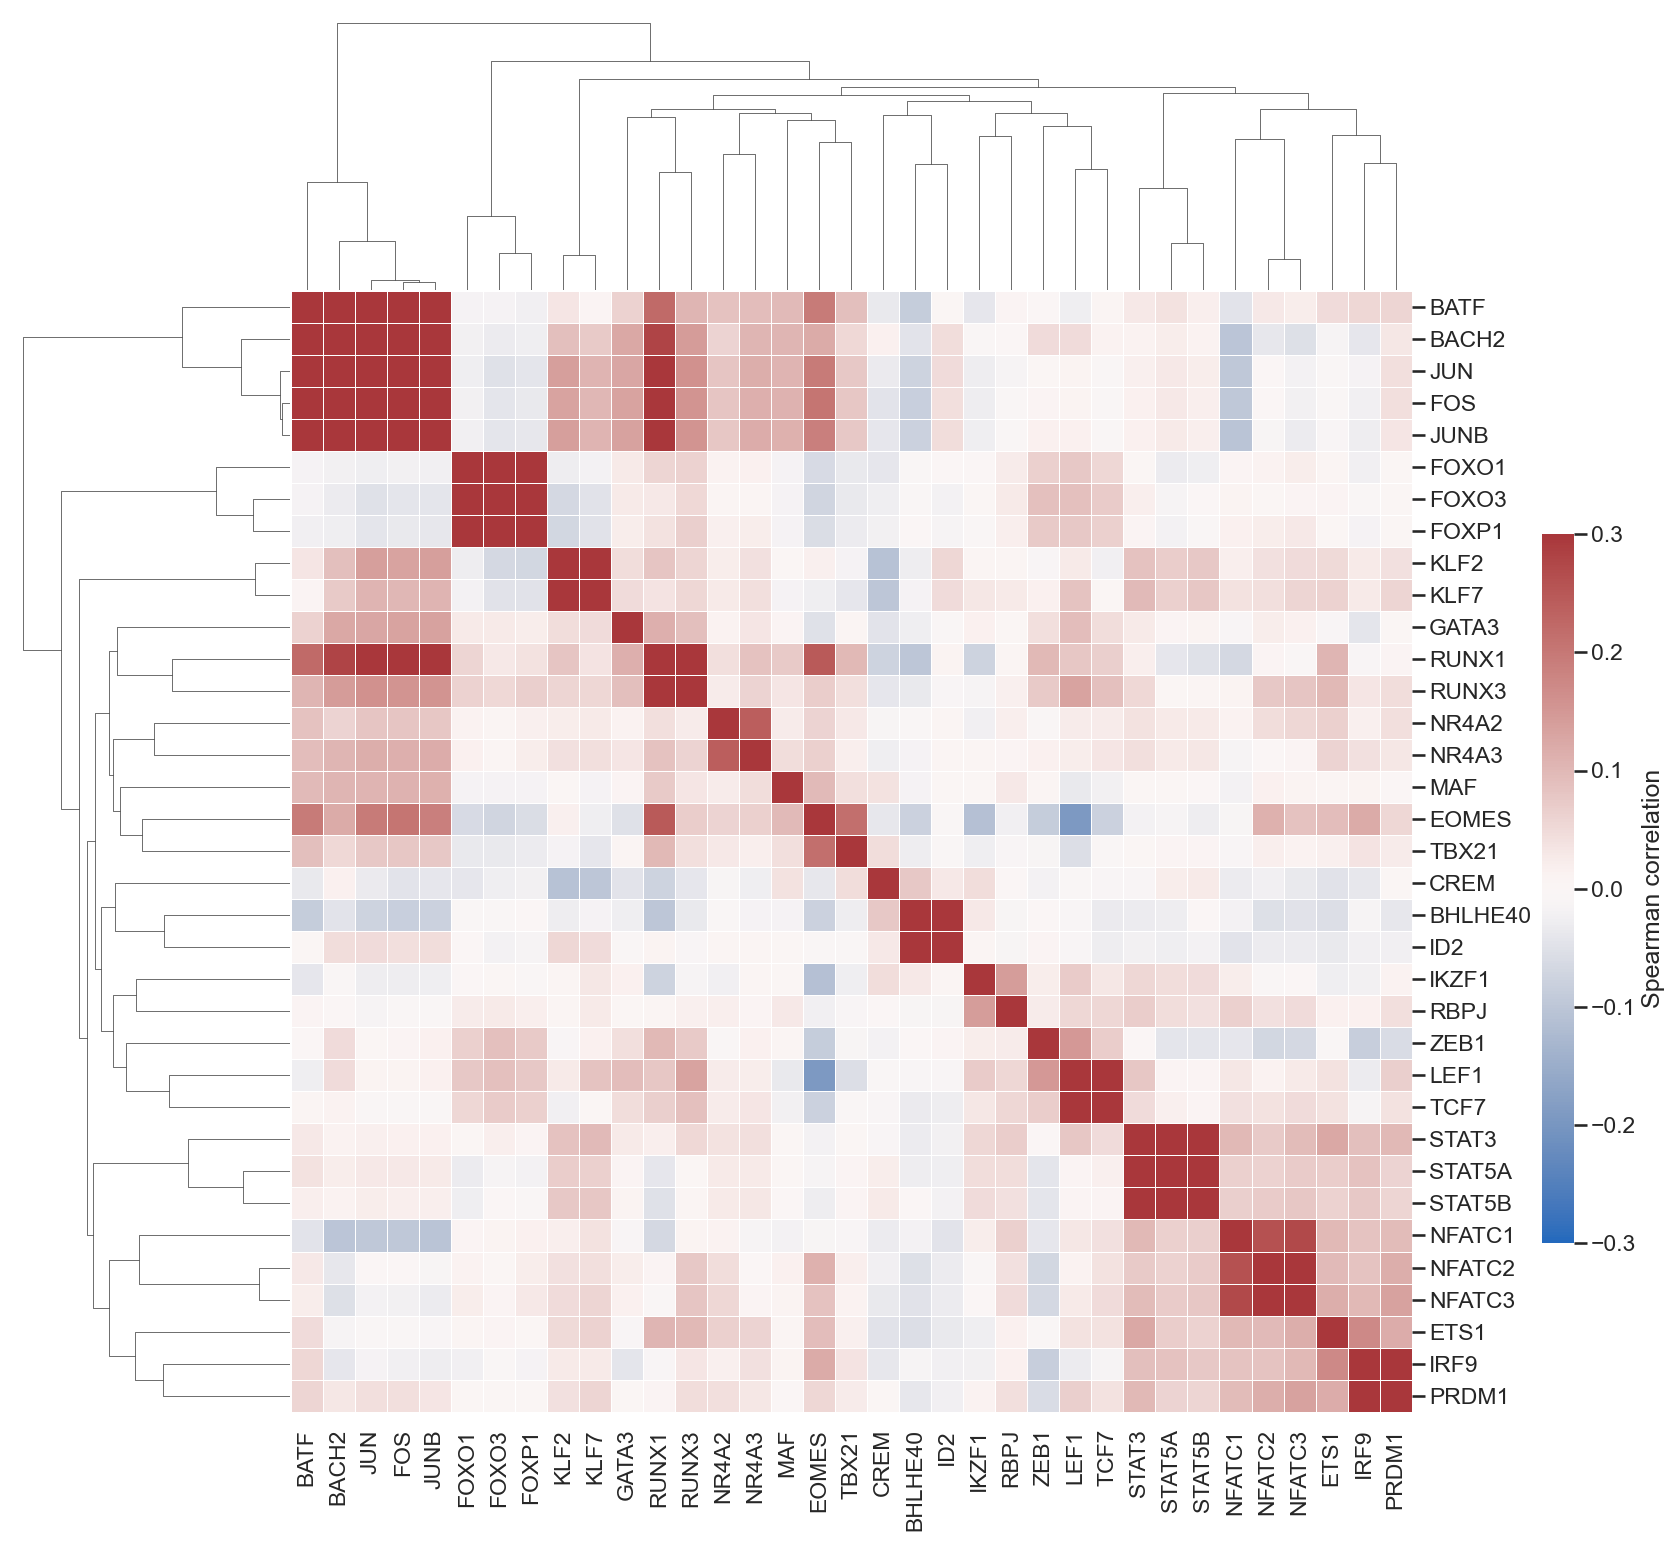

In [62]:
#sns.clustermap of the chromVAR correlation matrix with new clustering
cg = sns.clustermap(
    corr_all,
    cmap='vlag',
    center=0,
    linewidths=0.5,
    vmin=-0.3,
    vmax=0.3,
    figsize=(max(10, 0.45 * corr_all.shape[0]), max(8, 0.45 * corr_all.shape[0])),
    cbar_kws={"label": "Spearman correlation", "shrink": 0.6, "location": "right"},
    cbar_pos=(0.99, 0.2, 0.02, 0.45), 
    row_cluster=True,
    col_cluster=True,
)

In [63]:
def get_rna_tf_df(adata, tf_names):
    present_tfs = [tf for tf in tf_names if tf in adata.var_names]
    if not present_tfs:
        return pd.DataFrame(index=adata.obs_names), []

    rna_matrix = adata[:, present_tfs].X
    if hasattr(rna_matrix, 'toarray'):
        rna_matrix = rna_matrix.toarray()

    rna_tf_df = pd.DataFrame(rna_matrix, index=adata.obs_names, columns=present_tfs)
    return rna_tf_df, present_tfs


def classify_pair_relationship(rna_corr, chromvar_corr, pos_cut=0.3, neg_cut=-0.3):
    if pd.isna(rna_corr) or pd.isna(chromvar_corr):
        return 'unclear'

    if rna_corr >= pos_cut:
        rna_state = 'positive'
    elif rna_corr <= neg_cut:
        rna_state = 'negative'
    else:
        rna_state = 'weak'

    if chromvar_corr >= pos_cut:
        chromvar_state = 'positive'
    elif chromvar_corr <= neg_cut:
        chromvar_state = 'negative'
    else:
        chromvar_state = 'weak'

    if rna_state == 'positive' and chromvar_state == 'positive':
        return 'concordant_high_high'
    if rna_state == 'positive' and chromvar_state == 'weak':
        return 'rna_only'
    if rna_state == 'weak' and chromvar_state == 'positive':
        return 'chromvar_only'
    if (rna_state == 'positive' and chromvar_state == 'negative') or (rna_state == 'negative' and chromvar_state == 'positive'):
        return 'opposite_direction'
    if rna_state == 'negative' and chromvar_state == 'negative':
        return 'concordant_anti_correlated'
    return 'unclear'


## 4. Connect RNA Expression and chromVAR Activity

This section adds the RNA side back into the notebook and organizes the chromVAR connection at three practical levels:

1. **Single TF**: does a TF's RNA track with its own motif activity across clusters?
2. **TF pair across cells**: does the RNA-derived pair still move together when you look at single-cell chromVAR scores?
3. **TF pair across clusters**: does the pair stay associated after averaging within clusters, where the ATAC signal is usually easier to interpret?

The categories follow your interpretation framework:

- `concordant_high_high`: RNA-high and chromVAR-high in the same direction, which is the strongest evidence for a coordinated module.
- `rna_only`: correlated in RNA but not in chromVAR, suggesting a transcript-level state marker without clear shared motif activity.
- `chromvar_only`: correlated in chromVAR but not RNA, consistent with post-transcriptional regulation or family-level motif effects.
- `opposite_direction`: correlated in one modality but anti-correlated in the other, highlighting more nuanced biology.
- `concordant_anti_correlated`: both modalities point to mutual exclusivity rather than co-activation.


TFs shared between TF_list and chromVAR: 51
TFs with RNA available in adata.var_names: 49
TFs missing RNA values in adata.var_names; rho will be NaN for these TFs:
['ASCL1', 'NFATC4']


,TF,mean_rna_across_cells,mean_chromvar_across_cells,spearman_cluster_rna_vs_chromvar,pearson_cluster_rna_vs_chromvar
49,ZEB1,1.542,-0.004,0.915,0.917
25,LEF1,0.224,-0.006,0.855,0.738
47,TCF7,0.360,-0.004,0.818,0.794
20,IRF9,0.163,-0.004,0.794,0.532
23,KLF2,0.904,-0.001,0.745,0.662
50,ZNF683,0.038,-0.003,0.745,0.336
39,RORC,0.004,-0.002,0.733,0.626
46,TBX21,0.135,0.001,0.709,0.769
16,ID2,1.116,-0.001,0.612,0.586
17,ID3,0.005,-0.002,0.552,0.252


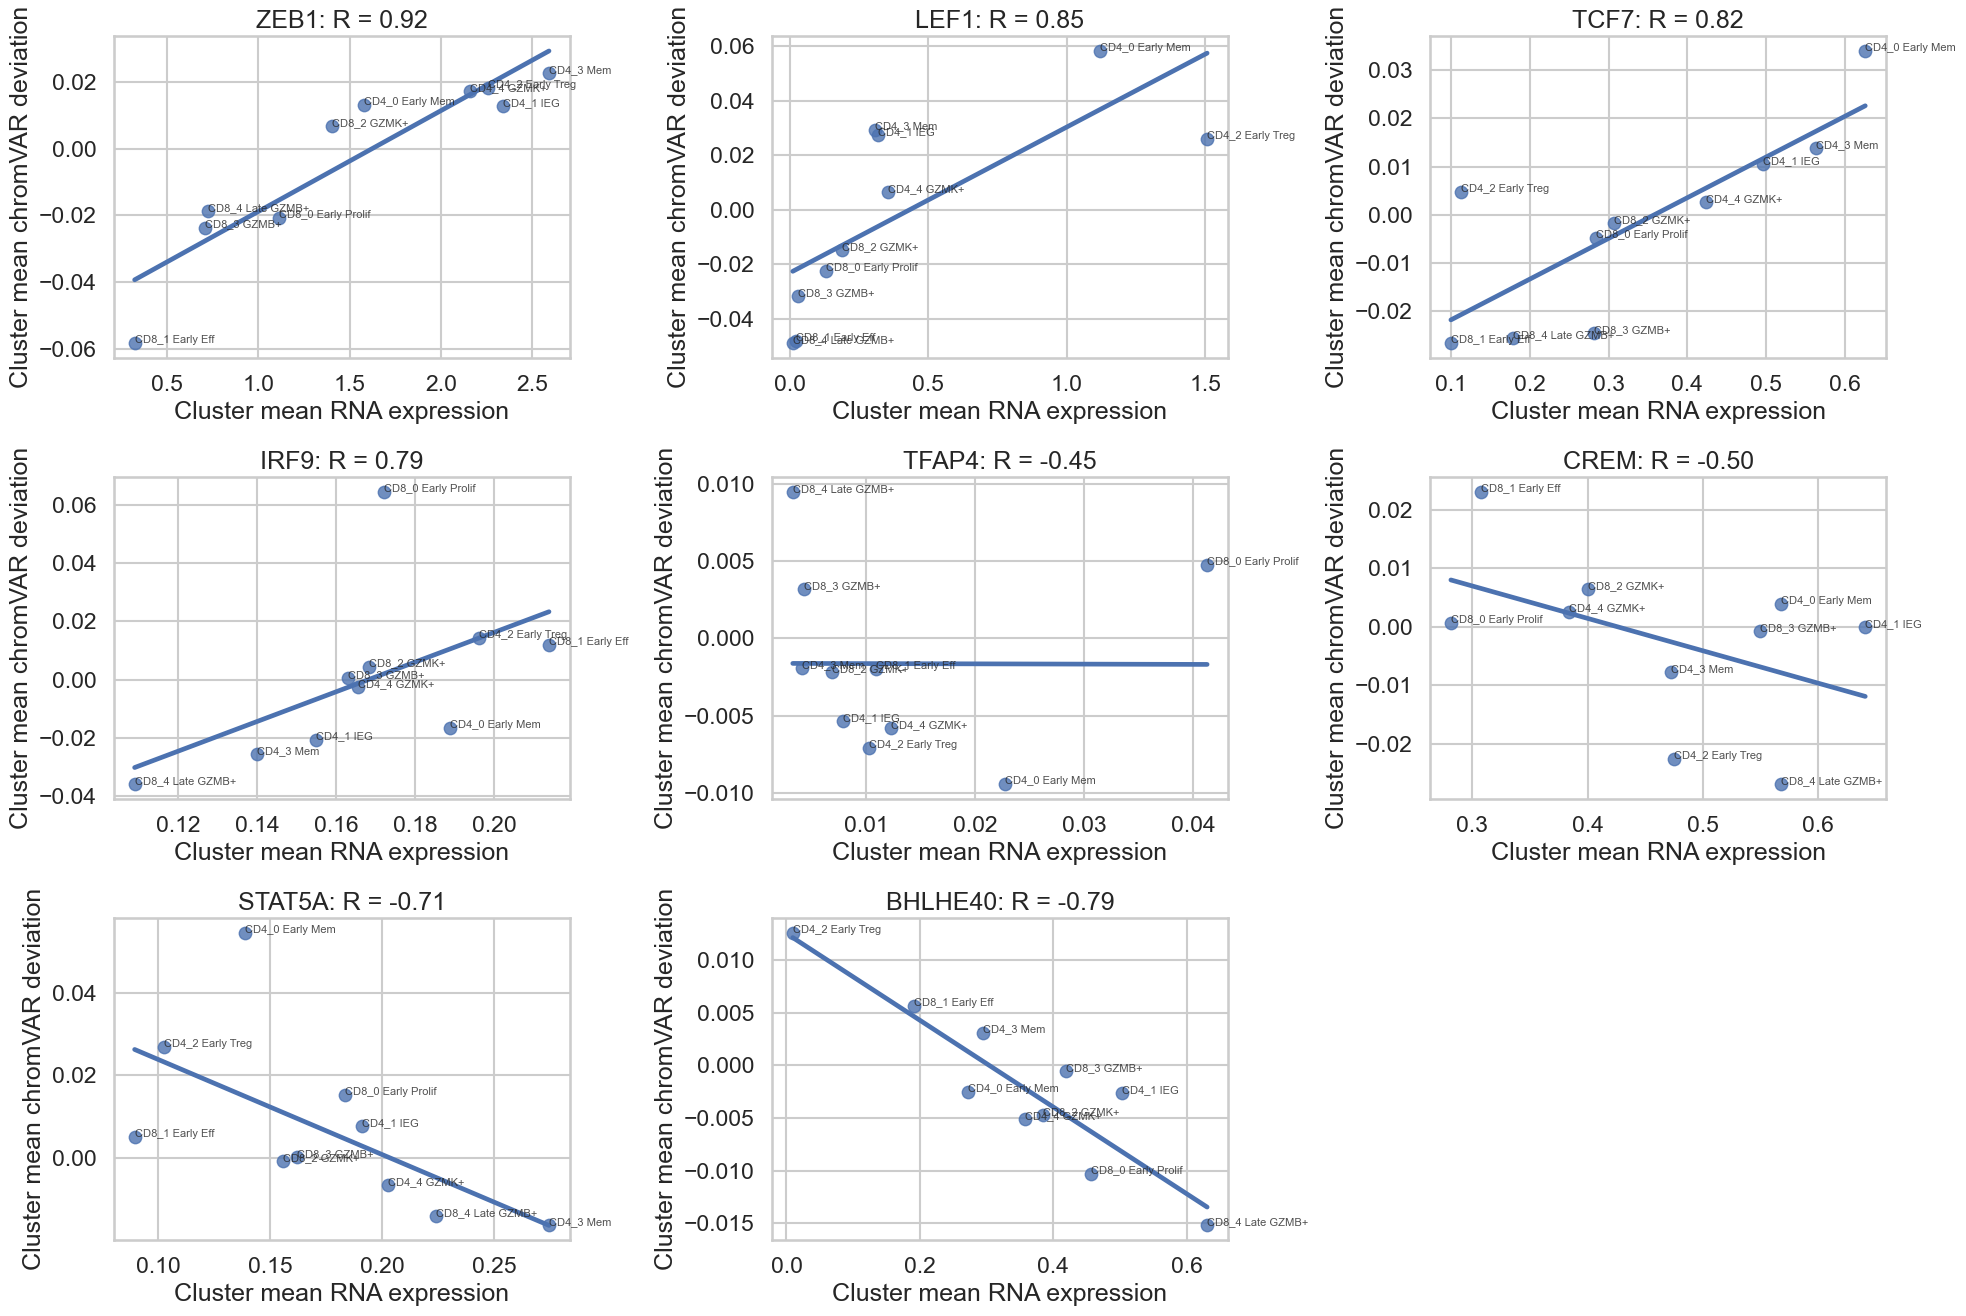

In [64]:
all_shared_tfs = sorted(shared_tf)
rna_available_tfs = [tf for tf in all_shared_tfs if tf in adata.var_names]
rna_missing_tfs = [tf for tf in all_shared_tfs if tf not in adata.var_names]

if not rna_available_tfs:
    raise ValueError('None of the shared TFs were found in adata.var_names for RNA comparison.')

rna_tf_df_all, present_rna_tfs_all = get_rna_tf_df(adata, rna_available_tfs)
chromvar_all_columns = chromvar_name_map.loc[all_shared_tfs].tolist()
chromvar_tf_df_all = chromvar_df.loc[:, chromvar_all_columns].copy()
chromvar_tf_df_all.columns = all_shared_tfs

cluster_order = sorted(cluster_labels.unique())
cluster_rna_means_all = rna_tf_df_all.groupby(cluster_labels).mean().loc[cluster_order]
cluster_chromvar_means_all = chromvar_tf_df_all.groupby(cluster_labels).mean().loc[cluster_order]

print(f'TFs shared between TF_list and chromVAR: {len(all_shared_tfs)}')
print(f'TFs with RNA available in adata.var_names: {len(rna_available_tfs)}')
if rna_missing_tfs:
    print('TFs missing RNA values in adata.var_names; rho will be NaN for these TFs:')
    print(rna_missing_tfs)

single_tf_results = []
for tf in all_shared_tfs:
    tf_row = {
        'TF': tf,
        'mean_rna_across_cells': np.nan,
        'mean_chromvar_across_cells': float(chromvar_tf_df_all[tf].mean()),
        'spearman_cluster_rna_vs_chromvar': np.nan,
        'pearson_cluster_rna_vs_chromvar': np.nan,
    }
    if tf in present_rna_tfs_all:
        tf_row['mean_rna_across_cells'] = float(rna_tf_df_all[tf].mean())
        tf_row['spearman_cluster_rna_vs_chromvar'] = float(cluster_rna_means_all[tf].corr(cluster_chromvar_means_all[tf], method='spearman'))
        tf_row['pearson_cluster_rna_vs_chromvar'] = float(cluster_rna_means_all[tf].corr(cluster_chromvar_means_all[tf], method='pearson'))
    single_tf_results.append(tf_row)

single_tf_results_df = pd.DataFrame(single_tf_results).sort_values(
    'spearman_cluster_rna_vs_chromvar', ascending=False
)

display(single_tf_results_df.round(3))

single_tf_plot_df = single_tf_results_df.dropna(subset=['spearman_cluster_rna_vs_chromvar']).copy()
plot_tf_subset = pd.concat([
    single_tf_plot_df.head(min(4, len(single_tf_plot_df))),
    single_tf_plot_df.tail(min(4, len(single_tf_plot_df)))
]).drop_duplicates('TF')

n_panels = len(plot_tf_subset)
n_cols = 3
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4.5 * n_rows), squeeze=False)

for ax, (_, row) in zip(axes.flat, plot_tf_subset.iterrows()):
    tf = row['TF']
    plot_df = pd.DataFrame({
        'cluster': cluster_order,
        'mean_rna': cluster_rna_means_all[tf].values,
        'mean_chromvar': cluster_chromvar_means_all[tf].values,
    })
    sns.regplot(data=plot_df, x='mean_rna', y='mean_chromvar', ci=None, scatter_kws={'s': 80}, ax=ax)
    for _, point in plot_df.iterrows():
        ax.text(point['mean_rna'], point['mean_chromvar'], point['cluster'], fontsize=8, alpha=0.8)
    ax.set_title(f"{tf}: R = {row['spearman_cluster_rna_vs_chromvar']:.2f}")
    ax.set_xlabel('Cluster mean RNA expression')
    ax.set_ylabel('Cluster mean chromVAR deviation')

for ax in axes.flat[n_panels:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


,TF,rho
49,ZEB1,0.915
25,LEF1,0.855
47,TCF7,0.818
20,IRF9,0.794
23,KLF2,0.745
50,ZNF683,0.745
39,RORC,0.733
46,TBX21,0.709
16,ID2,0.612
17,ID3,0.552


Histogram includes 49 TFs with RNA available out of 51 shared TFs total.


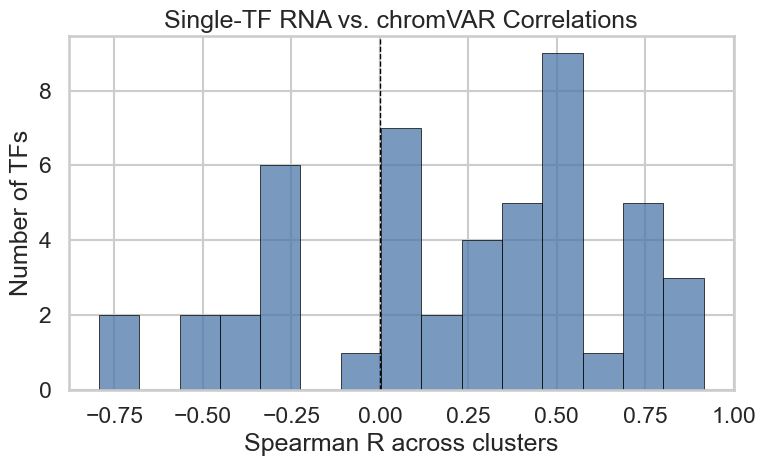

In [75]:
rho_df = single_tf_results_df[['TF', 'spearman_cluster_rna_vs_chromvar']].rename(
    columns={'spearman_cluster_rna_vs_chromvar': 'rho'}
)

display(rho_df.round(3))

rho_plot = rho_df['rho'].dropna()
print(f'Histogram includes {rho_plot.shape[0]} TFs with RNA available out of {rho_df.shape[0]} shared TFs total.')

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(rho_plot, bins=15, color='#4c78a8', edgecolor='black', linewidth=0.5, ax=ax)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Single-TF RNA vs. chromVAR Correlations')
ax.set_xlabel('Spearman R across clusters')
ax.set_ylabel('Number of TFs')
plt.tight_layout()
plt.show()


### Single-TF Interpretation

TFs near the top of the table have cluster-level RNA and motif activity that rise and fall together, so their transcript and inferred regulatory activity agree. TFs near the bottom are more discordant, which can happen when motif accessibility reflects a broader TF family, when regulation is post-transcriptional, or when the motif is not very specific for that gene.


Total pairs in overlap table: 136
Pairs with both TF motifs available in chromVAR: 57


,cluster_level
cluster_level_class,
unclear,29
concordant,22
discordant,6


,TF1,TF2,R_J,R_D,Rank_J,Rank_D,chromvar_corr_cells,chromvar_corr_clusters,cell_level_class,cluster_level_class,abs_cluster_gap
47,GATA3,RBPJ,0.648,0.976,171,1,0.002,0.455,unclear,concordant,0.521
35,LEF1,STAT5B,0.709,0.806,125,76,0.009,0.358,unclear,concordant,0.448
4,FOS,GATA3,0.855,0.745,22,118,0.133,0.333,unclear,concordant,0.412
46,FOXP1,LEF1,0.648,0.867,170,30,0.077,0.503,unclear,concordant,0.364
17,AHR,ZEB1,0.770,0.721,72,134,0.020,0.358,unclear,concordant,0.364
51,NFATC3,ZEB1,-0.576,-0.636,186,51,-0.068,-0.333,unclear,concordant,0.303
21,KLF7,LEF1,0.770,0.806,80,75,0.083,0.515,unclear,concordant,0.291
39,FOXO1,RBPJ,0.685,0.855,143,40,0.024,0.576,unclear,concordant,0.279
50,FOS,JUNB,0.636,0.721,183,138,0.960,0.976,concordant,concordant,0.255
20,FOXO1,ZEB1,0.770,0.794,77,78,0.065,0.552,unclear,concordant,0.242


,TF1,TF2,R_J,R_D,Rank_J,Rank_D,chromvar_corr_cells,chromvar_corr_clusters,cell_level_class,cluster_level_class,abs_cluster_gap
3,CREM,NR4A3,0.879,0.867,17,28,-0.026,-0.624,unclear,discordant,1.491
1,CREM,NR4A2,0.952,0.842,4,46,-0.012,-0.406,unclear,discordant,1.248
45,CREM,FOS,0.648,0.709,167,147,-0.045,-0.539,unclear,discordant,1.248
15,JUNB,LEF1,0.782,0.842,68,50,0.015,-0.345,unclear,discordant,1.188
30,BACH2,BATF,-0.648,-0.467,116,135,0.475,0.491,discordant,discordant,0.958
14,IRF9,STAT5A,-0.733,-0.358,66,200,0.087,0.539,unclear,discordant,0.897


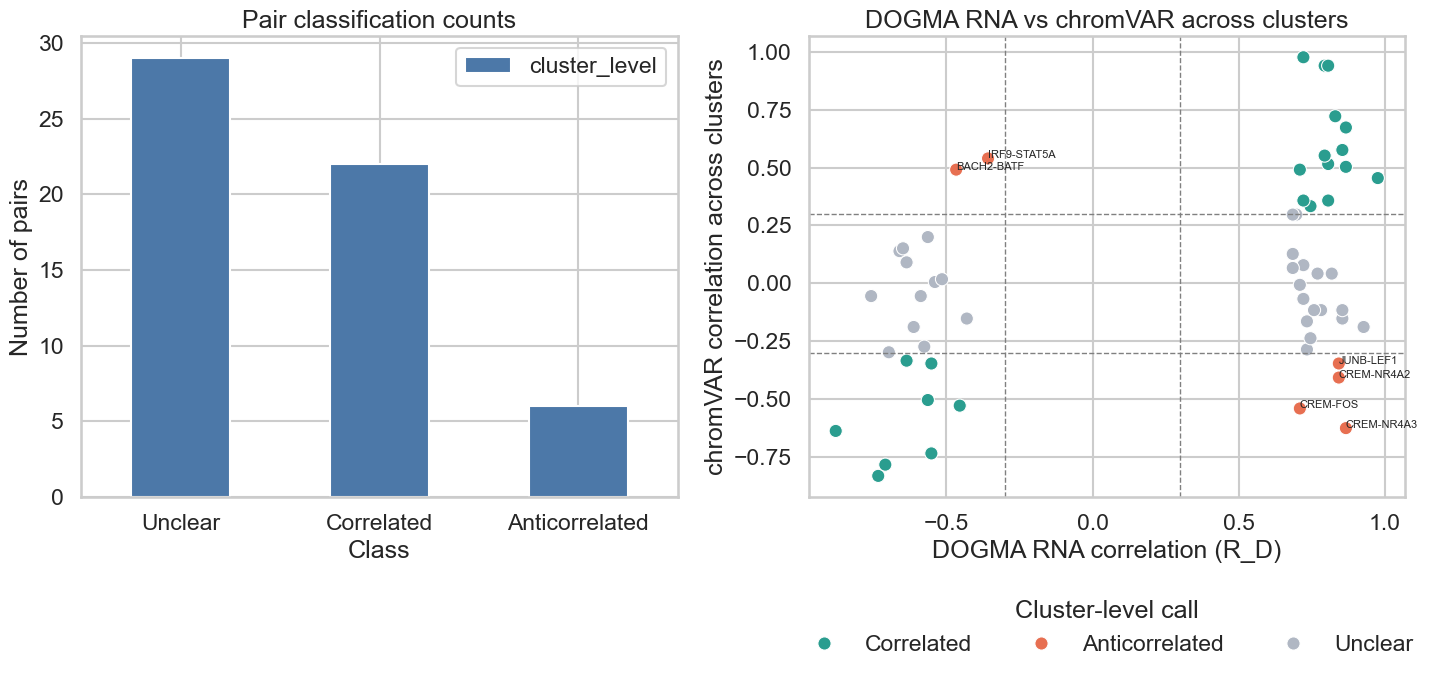

In [88]:
pair_overlap_path = '/Users/cherkass/Desktop/Leslie_Lab/TF_pairs/top200_correlation_pair_overlap_jurgens_dogma.csv'
pair_overlap_df = pd.read_csv(pair_overlap_path)

def classify_pair_concordance(rna_corr, chromvar_corr, corr_cut=0.3):
    if pd.isna(rna_corr) or pd.isna(chromvar_corr):
        return 'unclear'
    if abs(rna_corr) < corr_cut or abs(chromvar_corr) < corr_cut:
        return 'unclear'
    return 'concordant' if np.sign(rna_corr) == np.sign(chromvar_corr) else 'discordant'

pair_overlap_usable = pair_overlap_df[
    pair_overlap_df['TF1'].isin(chromvar_base_names) & pair_overlap_df['TF2'].isin(chromvar_base_names)
].copy()

if pair_overlap_usable.empty:
    raise ValueError('No pairs from the overlap CSV had both TF motifs present in chromVAR.')

pair_overlap_tfs = sorted(set(pair_overlap_usable['TF1']).union(set(pair_overlap_usable['TF2'])))
chromvar_pair_columns = chromvar_name_map.loc[pair_overlap_tfs].tolist()
chromvar_pair_df = chromvar_df.loc[:, chromvar_pair_columns].copy()
chromvar_pair_df.columns = pair_overlap_tfs
cluster_chromvar_means = chromvar_pair_df.groupby(cluster_labels).mean().loc[cluster_order]

print(f'Total pairs in overlap table: {len(pair_overlap_df)}')
print(f'Pairs with both TF motifs available in chromVAR: {len(pair_overlap_usable)}')

pair_results = []
for _, row in pair_overlap_usable.iterrows():
    tf1, tf2 = row['TF1'], row['TF2']
    chromvar_corr_cells = float(chromvar_pair_df[[tf1, tf2]].corr(method='spearman').iloc[0, 1])
    chromvar_corr_clusters = float(cluster_chromvar_means[[tf1, tf2]].corr(method='spearman').iloc[0, 1])

    pair_results.append({
        'TF1': tf1,
        'TF2': tf2,
        'R_J': row['R_J'],
        'R_D': row['R_D'],
        'Rank_J': row['Rank_J'],
        'Rank_D': row['Rank_D'],
        'chromvar_corr_cells': chromvar_corr_cells,
        'chromvar_corr_clusters': chromvar_corr_clusters,
        'cell_level_class': classify_pair_concordance(row['R_D'], chromvar_corr_cells),
        'cluster_level_class': classify_pair_concordance(row['R_D'], chromvar_corr_clusters),
    })

pair_results_df = pd.DataFrame(pair_results)
pair_results_df['abs_cluster_gap'] = (pair_results_df['R_D'] - pair_results_df['chromvar_corr_clusters']).abs()
pair_results_df = pair_results_df.sort_values(
    ['cluster_level_class', 'abs_cluster_gap', 'R_D'],
    ascending=[True, False, False]
)

summary_counts = pd.concat([
    #pair_results_df['cell_level_class'].value_counts().rename('cell_level'),
    pair_results_df['cluster_level_class'].value_counts().rename('cluster_level')
], axis=1).fillna(0).astype(int)

display(summary_counts)
display(pair_results_df.round(3))

display(pair_results_df.query("cluster_level_class == 'discordant'").head(15).round(3))

class_palette = {
    'concordant': '#2a9d8f',
    'discordant': '#e76f51',
    'unclear': '#b0b7c3',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

summary_counts.plot(kind='bar', ax=axes[0], color=['#4c78a8', '#f58518'])
axes[0].set_title('Pair classification counts')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of pairs')
axes[0].set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in axes[0].get_xticklabels()], rotation=0)
label_map = {
    'concordant': 'Correlated',
    'discordant': 'Anticorrelated',
    'unclear': 'Unclear',
}

sns.scatterplot(
    data=pair_results_df,
    x='R_D',
    y='chromvar_corr_clusters',
    hue='cluster_level_class',
    palette=class_palette,
    s=90,
    ax=axes[1],
)
label_pairs = pair_results_df.query("cluster_level_class == 'discordant'").head(10)
for _, row in label_pairs.iterrows():
    axes[1].text(row['R_D'], row['chromvar_corr_clusters'], f"{row['TF1']}-{row['TF2']}", fontsize=8)
axes[1].axhline(0.3, linestyle='--', color='grey', linewidth=1)
axes[1].axhline(-0.3, linestyle='--', color='grey', linewidth=1)
axes[1].axvline(0.3, linestyle='--', color='grey', linewidth=1)
axes[1].axvline(-0.3, linestyle='--', color='grey', linewidth=1)
axes[1].set_title('DOGMA RNA vs chromVAR across clusters')
axes[1].set_xlabel('DOGMA RNA correlation (R_D)')
axes[1].set_ylabel('chromVAR correlation across clusters')
handles, labels = axes[1].get_legend_handles_labels()
label_map = {
    'concordant': 'Correlated',
    'discordant': 'Anticorrelated',
    'unclear': 'Unclear',
}
axes[1].legend(
    handles=handles,
    labels=[label_map.get(label, label) for label in labels],
    title='Cluster-level call',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


### Pair-Level Interpretation

This section uses `/Users/cherkass/Desktop/Leslie_Lab/TF_pairs/top200_correlation_pair_overlap_jurgens_dogma.csv` as the RNA-derived pair table and compares each DOGMA RNA correlation (`R_D`) against chromVAR correlation in the same dataset.

- `concordant`: RNA and chromVAR correlations are both substantial and have the same sign.
- `discordant`: RNA and chromVAR correlations are both substantial but point in opposite directions.
- `unclear`: at least one modality is weak, so the pair is not strongly supported either way.

The cluster-level plot is usually the easiest one to interpret biologically, because chromVAR tends to stabilize after averaging within clusters. Pairs that land in the discordant cluster-level group are often the most interesting follow-up candidates.


In [89]:
#print list of correlated pairs
correlated_pairs = pair_results_df.query("cluster_level_class == 'concordant'")
print('Correlated pairs:')
display(correlated_pairs.round(3))

anti = pair_results_df.query("cluster_level_class == 'discordant'")
print('Anticorrelated pairs:')
display(anti.round(3))

Correlated pairs:


,TF1,TF2,R_J,R_D,Rank_J,Rank_D,chromvar_corr_cells,chromvar_corr_clusters,cell_level_class,cluster_level_class,abs_cluster_gap
47,GATA3,RBPJ,0.648,0.976,171,1,0.002,0.455,unclear,concordant,0.521
35,LEF1,STAT5B,0.709,0.806,125,76,0.009,0.358,unclear,concordant,0.448
4,FOS,GATA3,0.855,0.745,22,118,0.133,0.333,unclear,concordant,0.412
46,FOXP1,LEF1,0.648,0.867,170,30,0.077,0.503,unclear,concordant,0.364
17,AHR,ZEB1,0.770,0.721,72,134,0.020,0.358,unclear,concordant,0.364
51,NFATC3,ZEB1,-0.576,-0.636,186,51,-0.068,-0.333,unclear,concordant,0.303
21,KLF7,LEF1,0.770,0.806,80,75,0.083,0.515,unclear,concordant,0.291
39,FOXO1,RBPJ,0.685,0.855,143,40,0.024,0.576,unclear,concordant,0.279
50,FOS,JUNB,0.636,0.721,183,138,0.960,0.976,concordant,concordant,0.255
20,FOXO1,ZEB1,0.770,0.794,77,78,0.065,0.552,unclear,concordant,0.242


Anticorrelated pairs:


,TF1,TF2,R_J,R_D,Rank_J,Rank_D,chromvar_corr_cells,chromvar_corr_clusters,cell_level_class,cluster_level_class,abs_cluster_gap
3,CREM,NR4A3,0.879,0.867,17,28,-0.026,-0.624,unclear,discordant,1.491
1,CREM,NR4A2,0.952,0.842,4,46,-0.012,-0.406,unclear,discordant,1.248
45,CREM,FOS,0.648,0.709,167,147,-0.045,-0.539,unclear,discordant,1.248
15,JUNB,LEF1,0.782,0.842,68,50,0.015,-0.345,unclear,discordant,1.188
30,BACH2,BATF,-0.648,-0.467,116,135,0.475,0.491,discordant,discordant,0.958
14,IRF9,STAT5A,-0.733,-0.358,66,200,0.087,0.539,unclear,discordant,0.897
